# Summary Similarity Analysis

Detecting near-duplicate and highly similar case summaries in the SEC litigation dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('sec_litigation_releases_20260403_234416.csv', encoding='utf-8', on_bad_lines='skip')
print(f'Loaded {len(df):,} rows')

df = df[df['summary'].notna() & (df['summary'].str.len() > 50)].reset_index(drop=True)
print(f'After filtering empty/short summaries: {len(df):,} rows')

Loaded 10,914 rows
After filtering empty/short summaries: 10,914 rows


## 1. Vectorize Summaries

In [2]:
import re

def clean(text):
    text = str(text)
    text = re.sub(r'-{5,}.*?-{5,}', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:6000]

df['clean_summary'] = df['summary'].apply(clean)

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english'
)
X = tfidf.fit_transform(df['clean_summary'])
print(f'TF-IDF matrix: {X.shape}')

TF-IDF matrix: (10914, 8000)


## 2. Compute Pairwise Cosine Similarity (Batched)

With ~11K documents, a full pairwise matrix would be ~60M pairs. We process in batches and only store pairs above 70% similarity.

In [3]:
THRESHOLD = 0.70
BATCH_SIZE = 500
n = X.shape[0]

similar_pairs = []
all_max_sims = []

for start in range(0, n, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n)
    sim_block = cosine_similarity(X[start:end], X)

    for i_local in range(end - start):
        i_global = start + i_local
        row = sim_block[i_local]
        row[i_global] = 0  # exclude self-similarity

        max_sim = row.max()
        all_max_sims.append(max_sim)

        high_idx = np.where(row >= THRESHOLD)[0]
        for j in high_idx:
            if j > i_global:  # only store each pair once
                similar_pairs.append((i_global, j, row[j]))

    if (start // BATCH_SIZE) % 5 == 0:
        print(f'  Processed {end:,} / {n:,} rows — found {len(similar_pairs):,} similar pairs so far')

print(f'\nDone. Total pairs with similarity >= {THRESHOLD:.0%}: {len(similar_pairs):,}')

  Processed 500 / 10,914 rows — found 153 similar pairs so far


  Processed 3,000 / 10,914 rows — found 770 similar pairs so far


  Processed 5,500 / 10,914 rows — found 1,235 similar pairs so far


  Processed 8,000 / 10,914 rows — found 1,530 similar pairs so far


  Processed 10,500 / 10,914 rows — found 1,786 similar pairs so far



Done. Total pairs with similarity >= 70%: 1,816


## 3. Overall Similarity Profile

For each summary, what is the highest similarity it has with *any* other summary?

In [4]:
max_sims = np.array(all_max_sims)

bins = [0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 1.01]
labels = ['<30%', '30–50%', '50–70%', '70–80%', '80–90%', '90–95%', '95–100%']
counts = pd.cut(max_sims, bins=bins, labels=labels, right=False).value_counts().sort_index()

print('=== How similar is each summary to its closest match? ===')
print(f'{"Similarity Band":>15s}  {"Count":>7s}  {"% of Total":>10s}')
print('-' * 40)
for label, count in counts.items():
    pct = count / len(max_sims) * 100
    print(f'{label:>15s}  {count:>7,}  {pct:>9.1f}%')

print(f'\nTotal summaries: {len(max_sims):,}')
print(f'Summaries with a near-duplicate (>=90%): {(max_sims >= 0.90).sum():,} ({(max_sims >= 0.90).mean()*100:.1f}%)')
print(f'Summaries with a high match (>=80%):     {(max_sims >= 0.80).sum():,} ({(max_sims >= 0.80).mean()*100:.1f}%)')
print(f'Summaries with a moderate match (>=70%): {(max_sims >= 0.70).sum():,} ({(max_sims >= 0.70).mean()*100:.1f}%)')

=== How similar is each summary to its closest match? ===
Similarity Band    Count  % of Total
----------------------------------------
           <30%    1,424       13.0%
         30–50%    3,621       33.2%
         50–70%    3,461       31.7%
         70–80%    1,334       12.2%
         80–90%      809        7.4%
         90–95%      175        1.6%
        95–100%       90        0.8%

Total summaries: 10,914
Summaries with a near-duplicate (>=90%): 265 (2.4%)
Summaries with a high match (>=80%):     1,074 (9.8%)
Summaries with a moderate match (>=70%): 2,408 (22.1%)


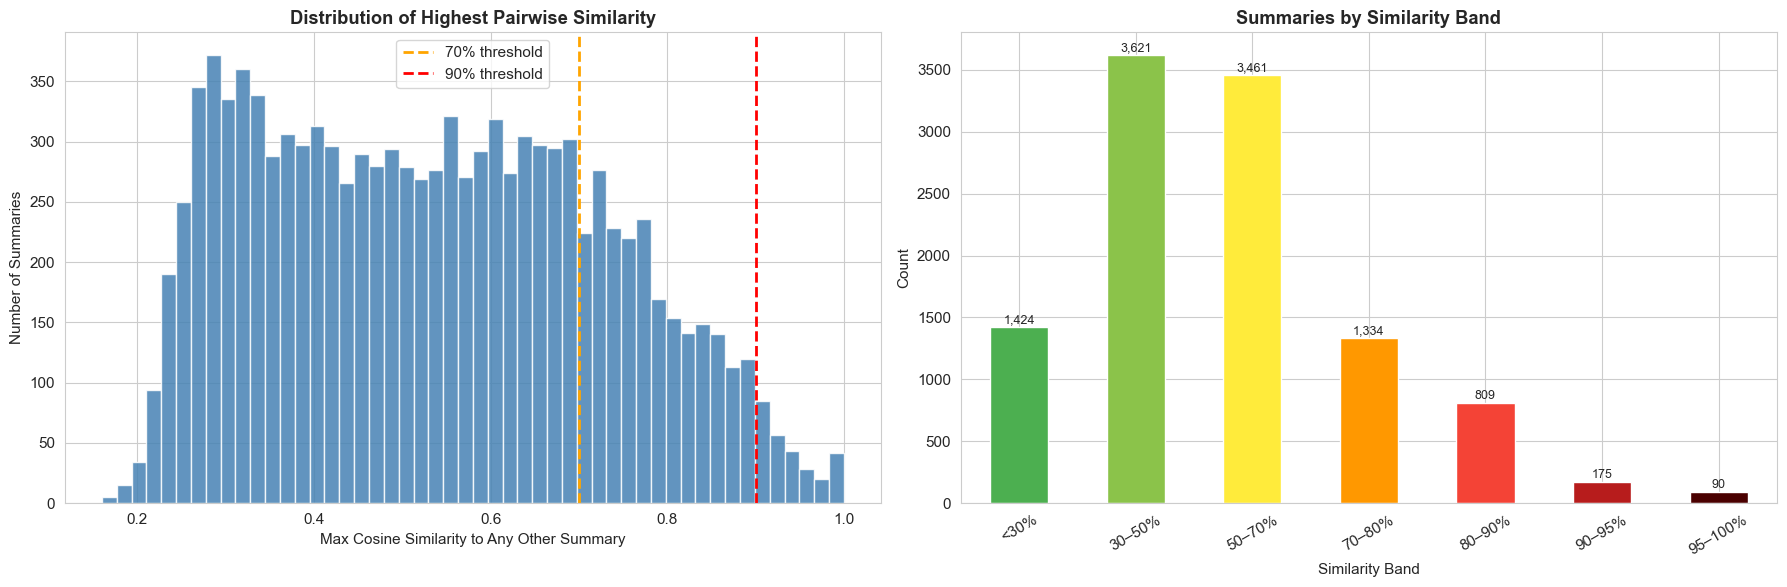

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].hist(max_sims, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0.7, color='orange', linestyle='--', linewidth=2, label='70% threshold')
axes[0].axvline(0.9, color='red', linestyle='--', linewidth=2, label='90% threshold')
axes[0].set_xlabel('Max Cosine Similarity to Any Other Summary')
axes[0].set_ylabel('Number of Summaries')
axes[0].set_title('Distribution of Highest Pairwise Similarity', fontweight='bold')
axes[0].legend()

colors = ['#4caf50', '#8bc34a', '#ffeb3b', '#ff9800', '#f44336', '#b71c1c', '#4a0000']
counts.plot.bar(ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Summaries by Similarity Band', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Similarity Band')
axes[1].tick_params(axis='x', rotation=30)
for i, (label, count) in enumerate(counts.items()):
    axes[1].text(i, count + 30, f'{count:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Near-Duplicate Pairs (>=90% Similarity)

In [6]:
pairs_df = pd.DataFrame(similar_pairs, columns=['idx_a', 'idx_b', 'similarity'])
pairs_df = pairs_df.sort_values('similarity', ascending=False).reset_index(drop=True)

pairs_df['case_a'] = pairs_df['idx_a'].map(df['case_title'])
pairs_df['case_b'] = pairs_df['idx_b'].map(df['case_title'])
pairs_df['date_a'] = pairs_df['idx_a'].map(df['date'])
pairs_df['date_b'] = pairs_df['idx_b'].map(df['date'])
pairs_df['similarity_pct'] = (pairs_df['similarity'] * 100).round(1)

near_dupes = pairs_df[pairs_df['similarity'] >= 0.90]
high_sim = pairs_df[(pairs_df['similarity'] >= 0.80) & (pairs_df['similarity'] < 0.90)]
moderate_sim = pairs_df[(pairs_df['similarity'] >= 0.70) & (pairs_df['similarity'] < 0.80)]

print(f'Similar pair counts (>= 70% cosine similarity):')
print(f'  90–100% (near-duplicates):  {len(near_dupes):,} pairs')
print(f'  80–90%  (high similarity):  {len(high_sim):,} pairs')
print(f'  70–80%  (moderate):         {len(moderate_sim):,} pairs')
print(f'  Total:                      {len(pairs_df):,} pairs')

Similar pair counts (>= 70% cosine similarity):
  90–100% (near-duplicates):  145 pairs
  80–90%  (high similarity):  539 pairs
  70–80%  (moderate):         1,132 pairs
  Total:                      1,816 pairs


In [7]:
print('=== Top 20 Most Similar Pairs ===')
print()
for _, row in pairs_df.head(20).iterrows():
    print(f'  {row["similarity_pct"]}%  |  {row["case_a"][:55]:55s}  ↔  {row["case_b"][:55]}')
    print(f'         |  {row["date_a"]}  ↔  {row["date_b"]}')
    print()

=== Top 20 Most Similar Pairs ===

  100.0%  |  Securities and Exchange Commission v. Peregrine Systems  ↔  Securities and Exchange Commission v. Peregrine Systems
         |  June 30, 2003  ↔  June 30, 2003

  100.0%  |  Securities and Exchange Commission v. J.C. Reed & Compa  ↔  Securities and Exchange Commission v. J.C. Reed & Compa
         |  March 14, 2013  ↔  March 14, 2013

  100.0%  |  Securities and Exchange Commission v. William K. Ichiok  ↔  Securities and Exchange Commission v. William K. Ichiok
         |  June 23, 2023  ↔  June 23, 2023

  100.0%  |  SECURITIES AND EXCHANGE COMMISSION v. STUART GREGORY SM  ↔  SECURITIES AND EXCHANGE COMMISSION v. STUART GREGORY SM
         |  July 10, 1997  ↔  July 24, 1997

  100.0%  |  Securities and Exchange Commission v. One or More Unkno  ↔  Securities and Exchange Commission v. One or More Unkno
         |  April 2, 2004  ↔  April 2, 2004

  100.0%  |  SECURITIES AND EXCHANGE COMMISSION v. DENNIS LINDSAY HE  ↔  SECURITIES AND EXCHA

## 5. Example: Side-by-Side Comparison of a Near-Duplicate Pair

In [8]:
if len(pairs_df) > 0:
    top_pair = pairs_df.iloc[0]
    idx_a, idx_b = int(top_pair['idx_a']), int(top_pair['idx_b'])

    print(f'Similarity: {top_pair["similarity_pct"]}%')
    print(f'\n{"=" * 80}')
    print(f'CASE A: {df.loc[idx_a, "case_title"]}')
    print(f'Date:   {df.loc[idx_a, "date"]}')
    print(f'{"=" * 80}')
    print(df.loc[idx_a, 'clean_summary'][:1500])

    print(f'\n{"=" * 80}')
    print(f'CASE B: {df.loc[idx_b, "case_title"]}')
    print(f'Date:   {df.loc[idx_b, "date"]}')
    print(f'{"=" * 80}')
    print(df.loc[idx_b, 'clean_summary'][:1500])
else:
    print('No similar pairs found above 70% threshold.')

Similarity: 100.0%

CASE A: Securities and Exchange Commission v. Peregrine Systems
Date:   June 30, 2003
Administrative Law Judge Orders and Initial Decisions Electronic Filings in Administrative Proceedings (eFAP) Public Alert: Unregistered Soliciting Entities (PAUSE) Administrative Law Judge Orders and Initial Decisions Electronic Filings in Administrative Proceedings (eFAP) Public Alert: Unregistered Soliciting Entities (PAUSE) Securities and Exchange Commission v. Peregrine Systems, Inc. , Civil Action No. 03 CV 1276 K (LAB) (S.D. Cal.) (June 30, 2003) SEC Charges Peregrine Systems, Inc. With Financial Fraud And Agrees To Partial Settlement The Securities and Exchange Commission today sued San Diego-based software company Peregrine Systems, Inc., in the United States District Court for the Southern District of California, for a massive financial fraud at the company that spanned 11 fiscal quarters. Simultaneously with the filing of the complaint, the Commission submitted to the Co

## 6. Are Similar Summaries About the Same Case?

In [9]:
if len(near_dupes) > 0:
    same_title = (near_dupes['case_a'].str[:30] == near_dupes['case_b'].str[:30]).sum()
    diff_title = len(near_dupes) - same_title

    print(f'Among {len(near_dupes):,} near-duplicate pairs (>=90% similarity):')
    print(f'  Same case title (follow-up releases): {same_title:,} ({same_title/len(near_dupes)*100:.1f}%)')
    print(f'  Different case titles:                {diff_title:,} ({diff_title/len(near_dupes)*100:.1f}%)')

    if diff_title > 0:
        print(f'\n  --- Different-case near-duplicates (top 10) ---')
        diff_pairs = near_dupes[near_dupes['case_a'].str[:30] != near_dupes['case_b'].str[:30]]
        for _, row in diff_pairs.head(10).iterrows():
            print(f'    {row["similarity_pct"]}%  {row["case_a"][:45]:45s}  ↔  {row["case_b"][:45]}')
else:
    print('No near-duplicate pairs found.')

Among 145 near-duplicate pairs (>=90% similarity):
  Same case title (follow-up releases): 122 (84.1%)
  Different case titles:                23 (15.9%)

  --- Different-case near-duplicates (top 10) ---
    100.0%  SEC v. John F. Aptt, Financial Instruments Gr  ↔  SEC v. James E. Washington, Jr., Dreams Unlim
    98.6%  SEC v. Mohamad Wael Ibrahim Elzein, Individua  ↔  SEC v. Mohamd Wael Ibrahim Elzein, Individual
    98.3%  SEC v. Cihaco International                    ↔  SEC  v.  Cihaco  International
    97.8%  SEC v. C. Roan Berry                           ↔  SEC v. Ashley J. Coots
    97.2%  SEC v. William E. Lyons                        ↔  SEC v. William E. Lyons (revised)
    96.1%  Securities and Exchange Commission v. Stephen  ↔  SECURITIES AND EXCHANGE COMMISSION v. STEPHEN
    95.4%  SEC v. Thomas P. Flanagan                      ↔  Securities and Exchange Commission v. Thomas 
    94.2%  SECURITIES AND EXCHANGE COMMISSION v. DAVID I  ↔  Securities And Exchange Commission

## 7. Similarity by Legal Topic — Which Topics Have the Most Duplicate Summaries?

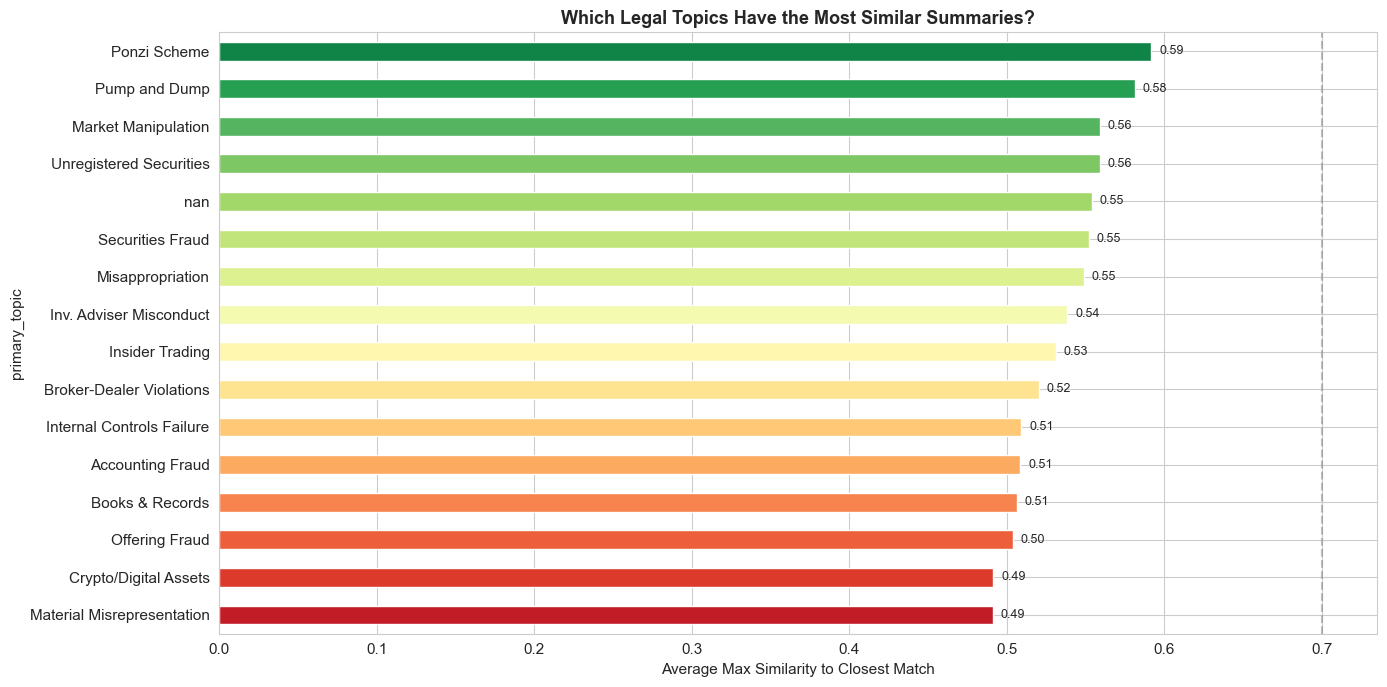

In [10]:
df['primary_topic'] = df['legal_topic'].astype(str).str.split(';').str[0].str.strip()

topic_sims = pd.DataFrame({'primary_topic': df['primary_topic'], 'max_sim': max_sims})
topic_avg = topic_sims.groupby('primary_topic')['max_sim'].agg(['mean', 'median', 'count'])
topic_avg = topic_avg[topic_avg['count'] >= 50].sort_values('mean', ascending=False)
topic_avg.columns = ['Mean Max Sim', 'Median Max Sim', 'Count']

fig, ax = plt.subplots(figsize=(14, 7))
topic_avg['Mean Max Sim'].plot.barh(ax=ax, color=sns.color_palette('RdYlGn_r', len(topic_avg)))
ax.invert_yaxis()
ax.set_xlabel('Average Max Similarity to Closest Match')
ax.set_title('Which Legal Topics Have the Most Similar Summaries?', fontweight='bold', fontsize=13)
ax.axvline(0.7, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(topic_avg['Mean Max Sim']):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('similarity_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [11]:
total = len(df)
print('=' * 60)
print('  SUMMARY SIMILARITY REPORT')
print('=' * 60)
print(f'  Total summaries analyzed:            {total:>8,}')
print(f'  Total similar pairs (>=70%):         {len(pairs_df):>8,}')
print(f'  Near-duplicate pairs (>=90%):        {len(near_dupes):>8,}')
print(f'  High similarity pairs (80–90%):      {len(high_sim):>8,}')
print(f'  Moderate similarity pairs (70–80%):  {len(moderate_sim):>8,}')
print()
print(f'  Summaries involved in near-dupes:    {(max_sims >= 0.90).sum():>8,}  ({(max_sims >= 0.90).mean()*100:.1f}% of all)')
print(f'  Summaries with no close match (<50%): {(max_sims < 0.50).sum():>7,}  ({(max_sims < 0.50).mean()*100:.1f}% of all)')
print()
print(f'  Mean max-similarity:                 {max_sims.mean():>8.3f}')
print(f'  Median max-similarity:               {np.median(max_sims):>8.3f}')
print('=' * 60)

  SUMMARY SIMILARITY REPORT
  Total summaries analyzed:              10,914
  Total similar pairs (>=70%):            1,816
  Near-duplicate pairs (>=90%):             145
  High similarity pairs (80–90%):           539
  Moderate similarity pairs (70–80%):     1,132

  Summaries involved in near-dupes:         265  (2.4% of all)
  Summaries with no close match (<50%):   5,045  (46.2% of all)

  Mean max-similarity:                    0.534
  Median max-similarity:                  0.526
